# **Task 1: Data Understanding & Cleaning**

## **1. Dataset Exploration**

In [ ]:
# importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the dataset and displaying five rows

df = pd.read_excel('zomato_rest_data.xlsx')
df.head()

,Unnamed: 0,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
# displaying the shape of the dataset

df.shape

(51717, 18)

In [ ]:
# list column names

df.columns

Index(['Unnamed: 0', 'url', 'address', 'name', 'online_order', 'book_table',
       'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked',
       'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [ ]:
# checking datatype of the columns

df.dtypes

,0
Unnamed: 0,int64
url,object
address,object
name,object
online_order,object
book_table,object
rate,object
votes,int64
phone,object
location,object


In [ ]:
# identifying the missing values

df.isnull().sum()

,0
Unnamed: 0,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21


## **2. Data Cleaning**

### i. Handling Duplicate data

In [ ]:
# checking how many duplicate records are there

df.duplicated().sum()

np.int64(0)

In [ ]:
# even though zero duplicates are there, let's drop the duplicates to be 100% sure.

# Removing duplicate records from the dataset

print("Shape of the dataset before removing duplicates: ", df.shape)
df.drop_duplicates(inplace=True)
print("Shape of the dataset after removing duplicates: ", df.shape)

Shape of the dataset before removing duplicates:  (51717, 18)
Shape of the dataset after removing duplicates:  (51717, 18)


### ii. Removing unwanted columns

In [ ]:
# let's drop unwanted columns before handling missing values
# unwamted columns are: unnamed: 0, url, address, phone, location, reviews_list, menu_item

df.drop(columns=['Unnamed: 0', 'url', 'address', 'phone', 'location', 'reviews_list', 'menu_item', 'rest_type'], axis = 1, inplace=True)

In [ ]:
# rename the columns: listed_in(type) to rest_type and listed_in(city) to location

d = {'listed_in(type)': 'rest_type', 'listed_in(city)': 'location'}
df.rename(columns=d, inplace=True)

### iii. Handling Missing Values

In [ ]:
# identifying the missing values

df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
dish_liked,28078
cuisines,45
approx_cost(for two people),346
rest_type,0
location,0


**Handling rate column**

In [ ]:
# the columns with missing values are: rate, rest_type, dish_liked, cuisines, approx_cost

# lets handle missing values in rate first
# checking what are all the unique values in rate column
print("Unique values of rate column: ", df['rate'].unique())

# replacing nan values in rate column with mean of rate column
# to do that we have to convert object datatype of rate column into float datatype
# we should also replace "NEW" and "-" with NaN and later with mean

df['rate'] = df['rate'].replace(['NEW', '-'], np.nan)
df['rate'] = df['rate'].str.strip('/5')
df['rate'] = df['rate'].astype(float)
df['rate'].fillna(df['rate'].mean(), inplace=True)

# check if the rate column datatype has been changed

print("Datatype of rate column: ", df['rate'].dtypes)

#check if rate column still has NaN values

print("Null value count in rate column: ", df['rate'].isnull().sum())

Unique values of rate column:  ['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5' '3.2/5' '3.3/5' '2.8/5' '4.4/5' '4.3/5' 'NEW' '2.9/5' '3.5/5' nan
 '2.6/5' '3.8 /5' '3.4/5' '4.5/5' '2.5/5' '2.7/5' '4.7/5' '2.4/5' '2.2/5'
 '2.3/5' '3.4 /5' '-' '3.6 /5' '4.8/5' '3.9 /5' '4.2 /5' '4.0 /5' '4.1 /5'
 '3.7 /5' '3.1 /5' '2.9 /5' '3.3 /5' '2.8 /5' '3.5 /5' '2.7 /5' '2.5 /5'
 '3.2 /5' '2.6 /5' '4.5 /5' '4.3 /5' '4.4 /5' '4.9/5' '2.1/5' '2.0/5'
 '1.8/5' '4.6 /5' '4.9 /5' '3.0 /5' '4.8 /5' '2.3 /5' '4.7 /5' '2.4 /5'
 '2.1 /5' '2.2 /5' '2.0 /5' '1.8 /5']
Datatype of rate column:  float64
Null value count in rate column:  0


/tmp/ipython-input-215/1786964578.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rate'].fillna(df['rate'].mean(), inplace=True)


**Handling dish_liked column**

In [ ]:
# checking the unique values in dish_liked column to decide the best way of replacing the NaN values
print("Unique values of dish_liked column: ", df['dish_liked'].unique())


# let's replace the NaN values in dish_liked column with mode

df['dish_liked'].fillna(df['dish_liked'].mode()[0], inplace=True)

# checking if the nulls are replaced or not
print("Null value count in dish_liked column: ", df['dish_liked'].isnull().sum())

Unique values of dish_liked column:  ['Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup'
 'Momos, Lunch Buffet, Chocolate Nirvana, Thai Green Curry, Paneer Tikka, Dum Biryani, Chicken Biryani'
 'Churros, Cannelloni, Minestrone Soup, Hot Chocolate, Pink Sauce Pasta, Salsa, Veg Supreme Pizza'
 ...
 'Noodles, Chicken Noodle, Momos, American Chopsuey, Salad, Manchow Soup, Manchurian'
 'Chicken Quesadilla, Naan, Breakfast Buffet, Cheesecake, Cocktails, Lunch Buffet, Biryani'
 'Biryani, Andhra Meal']
Null value count in dish_liked column:  0


/tmp/ipython-input-215/3568747170.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dish_liked'].fillna(df['dish_liked'].mode()[0], inplace=True)


**Handling cuisines column**

In [ ]:
# checking the unique values in cuisines column to decide the best way of replacing the NaN values
print("Unique values of cuisines column: ", df['cuisines'].unique())

# let's replace the NaN values in cuisines column with mode

df['cuisines'].fillna(df['cuisines'].mode()[0], inplace=True)

# checking if the nulls are replaced or not
print("Null value count in cuisines column: ", df['cuisines'].isnull().sum())

Unique values of cuisines column:  ['North Indian, Mughlai, Chinese' 'Chinese, North Indian, Thai'
 'Cafe, Mexican, Italian' ... 'North Indian, Street Food, Biryani'
 'Chinese, Mughlai' 'North Indian, Chinese, Arabian, Momos']
Null value count in cuisines column:  0


/tmp/ipython-input-215/762066763.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cuisines'].fillna(df['cuisines'].mode()[0], inplace=True)


**Handling approx_cost(for two people) column**

In [ ]:
# checking the unique values in approx_cost(for two people) column to decide the best way of replacing the NaN values
print("Unique values of approx_cost(for two people) column: ", df['approx_cost(for two people)'].unique())

# let's replace the missing values with mean of the data inside the column
# to perform that, we need to convert approx_cost(for two people) from object datatype to int datatype

# let's first remove commas in the string
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
# let's replace NaN values with 0
df['approx_cost(for two people)'].fillna(0, inplace=True)
# let's convert the datatype to int
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(int)

# now, lets replace 0 with mean of the data present in the column

df['approx_cost(for two people)'].replace(0, df['approx_cost(for two people)'].mean(), inplace=True)

# checking if the nulls are replaced or not
print("Null value count in approx_cost(for two people) column: ", df['approx_cost(for two people)'].isnull().sum())

Unique values of approx_cost(for two people) column:  ['800' '300' '600' '700' '550' '500' '450' '650' '400' '900' '200' '750'
 '150' '850' '100' '1,200' '350' '250' '950' '1,000' '1,500' '1,300' '199'
 '80' '1,100' '160' '1,600' '230' '130' '50' '190' '1,700' nan '1,400'
 '180' '1,350' '2,200' '2,000' '1,800' '1,900' '330' '2,500' '2,100'
 '3,000' '2,800' '3,400' '40' '1,250' '3,500' '4,000' '2,400' '2,600'
 '120' '1,450' '469' '70' '3,200' '60' '560' '240' '360' '6,000' '1,050'
 '2,300' '4,100' '5,000' '3,700' '1,650' '2,700' '4,500' '140']
Null value count in approx_cost(for two people) column:  0


/tmp/ipython-input-215/767714406.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['approx_cost(for two people)'].fillna(0, inplace=True)
/tmp/ipython-input-215/767714406.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [ ]:
# let's check if all the missing values have been handled

df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
dish_liked,0
cuisines,0
approx_cost(for two people),0
rest_type,0
location,0


In [ ]:
# let's check the datatype of the columns

df.dtypes

,0
name,object
online_order,object
book_table,object
rate,float64
votes,int64
dish_liked,object
cuisines,object
approx_cost(for two people),float64
rest_type,object
location,object


# **Task 2: Univariate Analysis**

## **1. Top 5 locations with highest number of restaurants**

performing the analysis with visualization for Top 5 locations with heighest number of restaurants

/tmp/ipython-input-215/4113338261.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='location', y='count', data=top5_restaurants, palette='magma')


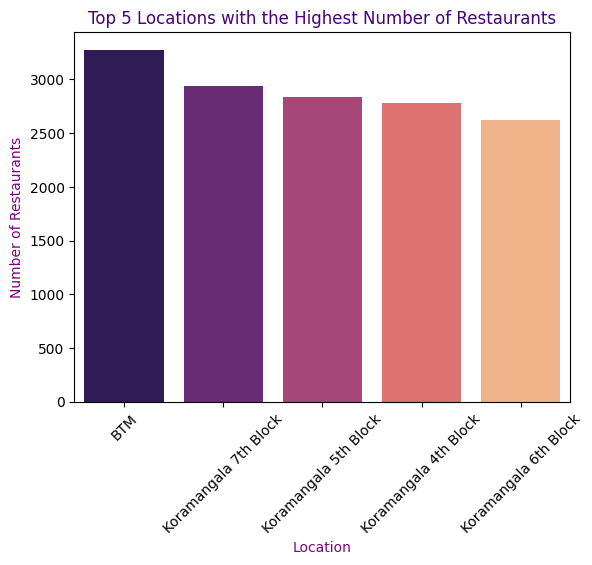

In [ ]:
# Grouping the data based on location and calculating the count of restaurants.

restaurant_count = df.groupby('location').size().reset_index(name='count' )
restaurant_count = restaurant_count.sort_values(by='count', ascending=False)
top5_restaurants = restaurant_count.head(5)

# visualizing the data using a bar chart with only top 5 restaurants
sns.barplot(x='location', y='count', data=top5_restaurants, palette='magma')
plt.xlabel('Location', color='purple')
plt.ylabel('Number of Restaurants', color='purple')
plt.title('Top 5 Locations with the Highest Number of Restaurants', color = 'indigo')
plt.xticks(rotation=45)
plt.show()

Hence, the top 5 locations with highest number of restaurants are: **BTM, Koramangala 7th Block, Koramangala 5th Block, Koramangala 4th Block, Koramangala 6th Block.**

## **2.  Distribution of restaurant ratings**
performing analysis with visualization for  Distribution of restaurant ratings

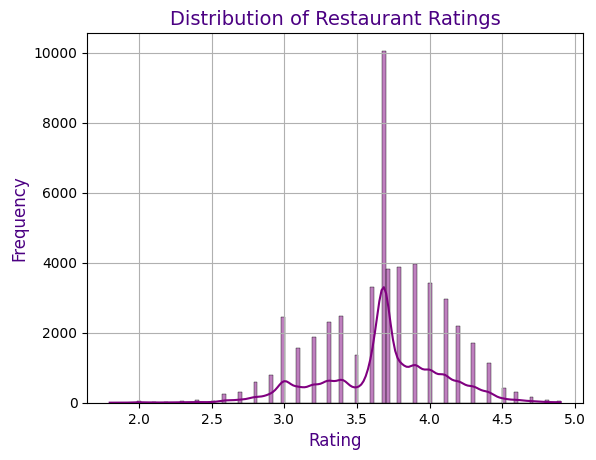

In [ ]:
# make a histplot to visualize the rating distribution

sns.histplot(df['rate'], kde=True, color='purple' )
plt.xlabel('Rating', fontsize=12, color='indigo')
plt.ylabel('Frequency', fontsize=12, color='indigo')
plt.title('Distribution of Restaurant Ratings', fontsize=14, color='indigo')
plt.grid()
plt.show()

Hence, we can see the distribution of restuarents in Bangalore.

**Mostly the restuarents are rated between 3.5-4**

## **3. Percentage of restaurants offering online orders**
performing analysis and visualization for percentage of restaurants offering online orders

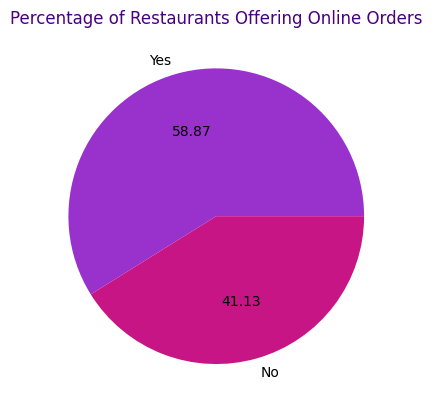

In [ ]:
# making a pie chart to visualize the percentage of restaurants offering online orders
plt.pie(df['online_order'].value_counts(), labels=df['online_order'].unique(), autopct='%0.2f', colors=['darkorchid', 'mediumvioletred'])
plt.title('Percentage of Restaurants Offering Online Orders',color = 'indigo' )
plt.show()


We can see that, **Most people prefer to order online from the restuarents with percentage of 58.87%**

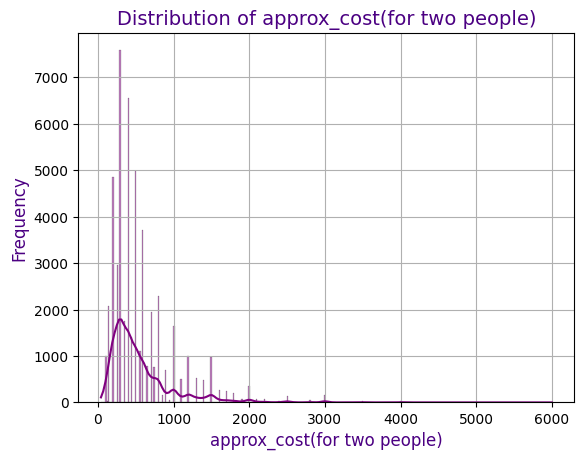

In [ ]:
# make a histplot to visualize the distribution of average cost of two

sns.histplot(df['approx_cost(for two people)'], kde=True, color='purple' )
plt.xlabel('approx_cost(for two people)', fontsize=12, color='indigo')
plt.ylabel('Frequency', fontsize=12, color='indigo')
plt.title('Distribution of approx_cost(for two people)', fontsize=14, color='indigo')
plt.grid()
plt.show()

# **Task 3: Bivariate Analysis**

## **1.  Rating vs Cost**
Analyzing the relationship between: Rating & Cost

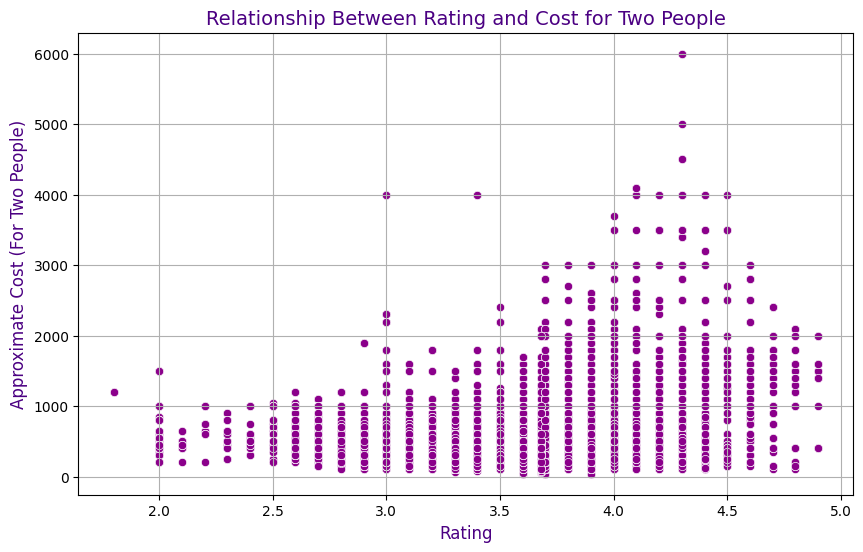

In [ ]:
# making a scatter plot to understand the relation between rating and cost

plt.figure(figsize=(10, 6))

sns.scatterplot(x='rate', y='approx_cost(for two people)', data=df, color='darkmagenta')

plt.xlabel('Rating', fontsize=12, color='indigo')
plt.ylabel('Approximate Cost (For Two People)', fontsize=12, color='indigo')
plt.title('Relationship Between Rating and Cost for Two People', fontsize=14, color='indigo')
plt.grid()
plt.show()

we can see that, the rating of the restuarent increases with the cost too.

## **2. Rating vs Online Order**
Analyzing the relationship between: Rating & Online Orders


/tmp/ipython-input-215/417966723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='online_order', y='rate', data=df, palette='magma')


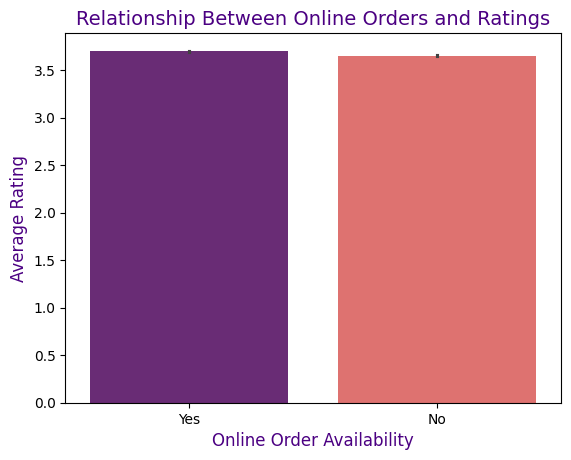

In [ ]:
# making a bar chart to analyize and visualize the relation between Rating and Online orders

sns.barplot(x='online_order', y='rate', data=df, palette='magma')
plt.xlabel('Online Order Availability', fontsize=12, color='indigo')
plt.ylabel('Average Rating', fontsize=12, color='indigo')
plt.title('Relationship Between Online Orders and Ratings',fontsize=14,color='indigo')
plt.show()


we can see that, **Same ratings are present for both online and offline orders**

## **3. Votes vs Rating**
Analyzing the relation between: Votes & Rating

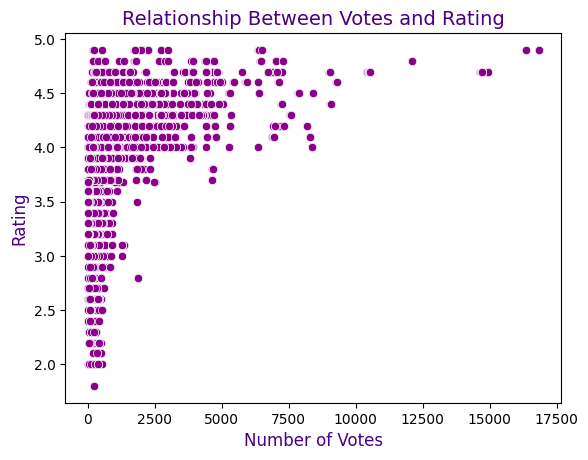

In [ ]:
# making a line plot to analyze the relation between Votes and Rating

sns.scatterplot(x='votes', y='rate', data=df, color='darkmagenta')
plt.xlabel('Number of Votes', fontsize=12, color='indigo')
plt.ylabel('Rating', fontsize=12, color='indigo')
plt.title('Relationship Between Votes and Rating', fontsize=14, color='indigo')
plt.show()


We can see that, **if the restuarent is good, people take an initiative to vote a high rating for it**

# **Task 4: Business Insights & Recommendations**

## **1. Does higher cost lead to higher ratings?**

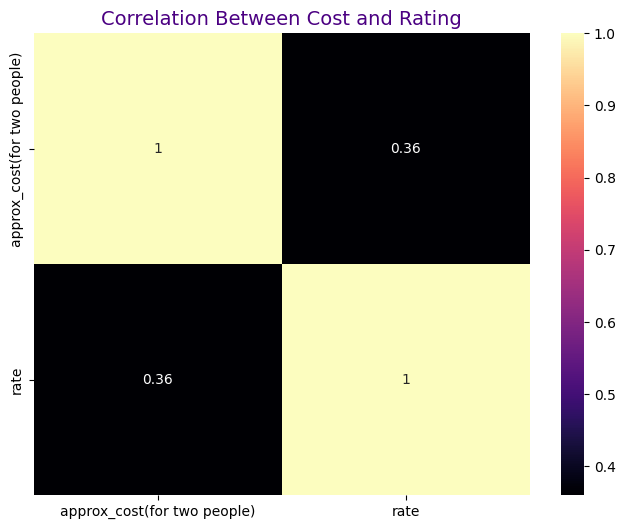

In [ ]:
# let's calculate the correlation and analyze it using heatmap

plt.figure(figsize=(8, 6))
corr = df[['approx_cost(for two people)', 'rate']].corr()
sns.heatmap(corr, annot=True, cmap='magma')
plt.title('Correlation Between Cost and Rating', fontsize=14, color='indigo')
plt.show()

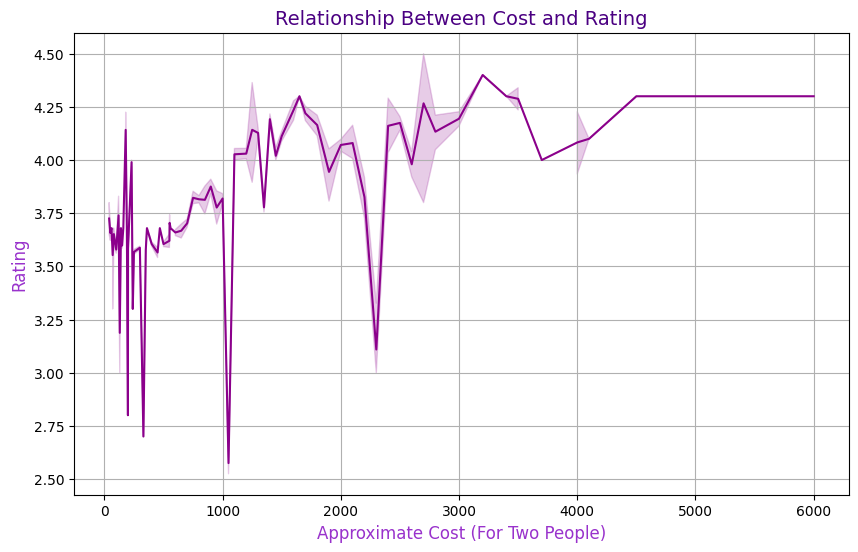

In [ ]:
# let's calculate the correlation and analyze it using heatmap

df_sorted = df.sort_values('approx_cost(for two people)')
plt.figure(figsize=(10, 6))
sns.lineplot(x='approx_cost(for two people)', y='rate', data=df_sorted, color='darkmagenta')
plt.xlabel('Approximate Cost (For Two People)', fontsize=12, color='darkorchid')
plt.ylabel('Rating', fontsize=12, color='darkorchid')
plt.title('Relationship Between Cost and Rating', fontsize=14, color='indigo')
plt.grid()
plt.show()

We can see that, the overall trend increases as the approximate cost for two people increases

Hence, we can say that **Rating increases as the cost increases**

## **2. Does offering online order impact ratings?**

In [ ]:
# let's group the data based on online order and calculate the average of the ratings.
avg_rating_online = df.groupby('online_order')['rate'].mean()
avg_rating_online

,rate
online_order,
No,3.651552
Yes,3.699491


We can see from the data that both online and offline orders have approximately same ratings.

Hence, **offering online order does not impact ratings**

## **3. Which location appears highly competitive?**

In [ ]:
# let's group the data based on location and calculate their value counts

location_count = df.groupby('location').size().reset_index(name='count')
location_count = location_count.sort_values(by='count', ascending=False)
location_count

,location,count
0,BTM,3279
19,Koramangala 7th Block,2938
17,Koramangala 5th Block,2836
16,Koramangala 4th Block,2779
18,Koramangala 6th Block,2623
13,Jayanagar,2371
12,JP Nagar,2096
11,Indiranagar,1860
7,Church Street,1827
21,MG Road,1811


We can see that most orders are placed from the location **BTM**.

Hence, **BTM appears to be highly competitive location**.

## **4. Where would you recommend opening a new restaurant?**


In [ ]:
# let's group the data based on location and calculate their value counts

location_count = df.groupby('location').size().reset_index(name='count')
location_count = location_count.sort_values(by='count')
location_count

,location,count
24,New BEL Road,740
1,Banashankari,863
26,Rajajinagar,1079
22,Malleshwaram,1096
9,Frazer Town,1185
4,Bellandur,1227
8,Electronic City,1229
28,Sarjapur Road,1261
3,Basavanagudi,1266
14,Kalyan Nagar,1309


We can see that, the least number of orders are from **New BEL Road, Banashankari, Rajajinagar**.

Hence, **A location to open a restuarant is New BEL Road, Banashankari, Rajajinagar**

In [ ]:
df.to_csv('zomato dataset.csv')